In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import random

# ----------------------------
# Paths
# ----------------------------
DATASET_PATH = "/content/drive/My Drive/UrbanSound8K/audio"
METADATA_PATH = "/content/drive/My Drive/UrbanSound8K/metadata/UrbanSound8K.csv"

# ----------------------------
# Parameters
# ----------------------------
SAMPLE_RATE = 22050
DURATION = 4  # seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION
N_MELS = 128
MAX_LEN = 128  # spectrogram width (time steps)

# ----------------------------
# Load metadata
# ----------------------------
metadata = pd.read_csv(METADATA_PATH)

# ----------------------------
# Augmentation Functions
# ----------------------------
def augment_audio(signal, sr):
    """Apply random audio augmentation with safety checks"""
    choice = random.choice(["none", "noise", "shift", "pitch", "stretch"])

    try:
        if choice == "noise":
            noise = np.random.normal(0, 0.005, signal.shape)
            signal = signal + noise

        elif choice == "shift":
            shift = np.random.randint(int(0.1*sr), int(0.3*sr))
            signal = np.roll(signal, shift)

        elif choice == "pitch":
            signal = librosa.effects.pitch_shift(signal, sr=sr,
                                                 n_steps=random.choice([-2, -1, 1, 2]))

        elif choice == "stretch":
            rate = random.uniform(0.8, 1.2)
            if len(signal) > 0:
                signal = librosa.effects.time_stretch(signal, rate)
            # pad/cut after stretching
            if len(signal) > SAMPLES_PER_TRACK:
                signal = signal[:SAMPLES_PER_TRACK]
            else:
                pad_width = SAMPLES_PER_TRACK - len(signal)
                signal = np.pad(signal, (0, pad_width), "constant")

    except Exception as e:
        print(f"⚠️ Augmentation failed: {e}")
        # return original if augmentation fails
        return signal

    return signal


def spec_augment(mel_db, num_mask=2, freq_masking_max_percentage=0.15, time_masking_max_percentage=0.2):
    """Apply SpecAugment on Mel spectrogram"""
    augmented = mel_db.copy()
    num_mel_channels = augmented.shape[0]
    num_time_steps = augmented.shape[1]

    for _ in range(num_mask):
        # Frequency masking
        freq_percentage = random.uniform(0.0, freq_masking_max_percentage)
        num_freqs_to_mask = int(freq_percentage * num_mel_channels)
        if num_freqs_to_mask > 0:
            f0 = random.randint(0, num_mel_channels - num_freqs_to_mask)
            augmented[f0:f0 + num_freqs_to_mask, :] = 0

        # Time masking
        time_percentage = random.uniform(0.0, time_masking_max_percentage)
        num_times_to_mask = int(time_percentage * num_time_steps)
        if num_times_to_mask > 0:
            t0 = random.randint(0, num_time_steps - num_times_to_mask)
            augmented[:, t0:t0 + num_times_to_mask] = 0

    return augmented

# ----------------------------
# Preprocessing Loop
# ----------------------------
features = []
labels = []

print("🎵 Extracting spectrograms with augmentation...")

for index, row in tqdm(metadata.iterrows(), total=len(metadata)):
    file_name = os.path.join(DATASET_PATH, f"fold{row['fold']}", row["slice_file_name"])
    label = row["classID"]

    try:
        # Load audio
        signal, sr = librosa.load(file_name, sr=SAMPLE_RATE)

        # Ensure fixed length
        if len(signal) > SAMPLES_PER_TRACK:
            signal = signal[:SAMPLES_PER_TRACK]
        else:
            pad_width = SAMPLES_PER_TRACK - len(signal)
            signal = np.pad(signal, (0, pad_width), "constant")

        # Randomly augment (50% probability)
        if random.random() > 0.5:
            signal = augment_audio(signal, sr)

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # SpecAugment (30% probability)
        if random.random() > 0.7:
            mel_db = spec_augment(mel_db)

        # Fix size for CNN
        if mel_db.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode="constant")
        else:
            mel_db = mel_db[:, :MAX_LEN]

        features.append(mel_db)
        labels.append(label)

    except Exception as e:
        print(f"❌ Error with file {file_name}: {e}")

# ----------------------------
# Save Dataset
# ----------------------------
X = np.array(features)
y = np.array(labels)

# Add channel dimension for CNN
X = X[..., np.newaxis]  # shape: (samples, 128, 128, 1)

np.save("X_aug.npy", X)
np.save("y_aug.npy", y)

print(f"✅ Preprocessing Done! Saved X_aug.npy ({X.shape}) and y_aug.npy ({y.shape})")


🎵 Extracting spectrograms with augmentation...


  0%|          | 27/8732 [00:00<02:59, 48.57it/s]

⚠️ Augmentation failed: time_stretch() takes 1 positional argument but 2 were given


  1%|          | 51/8732 [00:01<03:52, 37.33it/s]

⚠️ Augmentation failed: time_stretch() takes 1 positional argument but 2 were given
⚠️ Augmentation failed: time_stretch() takes 1 positional argument but 2 were given


...

⚠️ Augmentation failed: time_stretch() takes 1 positional argument but 2 were given


100%|█████████▉| 8731/8732 [42:51<00:00,  3.06it/s]

⚠️ Augmentation failed: time_stretch() takes 1 positional argument but 2 were given


100%|██████████| 8732/8732 [42:51<00:00,  3.40it/s]


✅ Preprocessing Done! Saved X_aug.npy ((8732, 128, 128, 1)) and y_aug.npy ((8732,))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2259 - loss: 3.9637 - val_accuracy: 0.3200 - val_loss: 2.7639
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3690 - loss: 1.8131 - val_accuracy: 0.3303 - val_loss: 1.8697
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4613 - loss: 1.5265 - val_accuracy: 0.3635 - val_loss: 1.7940
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5277 - loss: 1.3746 - val_accuracy: 0.4104 - val_loss: 2.3070
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6035 - loss: 1.0885 - val_accuracy: 0.5621 - val_loss: 1.4447
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6667 - loss: 0.9492 - val_accuracy: 0.6566 - val_loss: 1.1129
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7177 - loss: 0.8124 - val_accuracy: 0.6440 - val_loss: 1.0537
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7562 - loss: 0.6773 - val_acc

✅ Model trained and saved as sound_cnn_model.h5


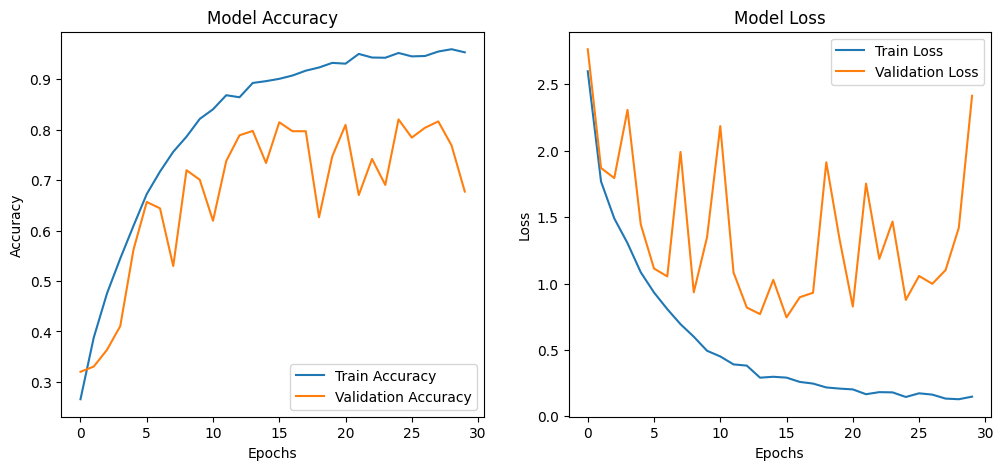

In [ ]:
# dont refer this
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ------------------------------
# Load preprocessed dataset
# ------------------------------
X = np.load("X_aug.npy")   # shape: (samples, 128, 128, 1)
y = np.load("y_aug.npy")   # shape: (samples,)

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=10)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# CNN Model
# ------------------------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 sound classes
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------
# Training
# ------------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

# Save the model
model.save("sound_cnn_model.h5")
print("✅ Model trained and saved as sound_cnn_model.h5")

# ------------------------------
# Plot Accuracy & Loss
# ------------------------------
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.savefig("model_accuracy.png")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.savefig("model_loss.png")
plt.legend()

plt.show()


In [ ]:
import librosa
import numpy as np
import tensorflow as tf
import os

# ----------------------------
# Parameters (must match preprocessing)
# ----------------------------
SAMPLE_RATE = 22050
DURATION = 4  # seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION
N_MELS = 128
MAX_LEN = 128  # spectrogram width (time steps)

# ------------------------------
# Load the trained model (replace with the path to your saved model)
# ------------------------------
try:
    model = tf.keras.models.load_model("best_sound_cnn.h5")
    print("✅ Trained model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    model = None # Set model to None if loading fails

# ------------------------------
# Function to preprocess a single audio file
# ------------------------------
def preprocess_audio_for_prediction(audio_path):
    """
    Loads an audio file, preprocesses it, and returns a ready-to-predict spectrogram.
    """
    if not os.path.exists(audio_path):
        print(f"❌ Error: Audio file not found at {audio_path}")
        return None

    try:
        # Load audio
        signal, sr = librosa.load(audio_path, sr=SAMPLE_RATE)

        # Ensure fixed length
        if len(signal) > SAMPLES_PER_TRACK:
            signal = signal[:SAMPLES_PER_TRACK]
        else:
            pad_width = SAMPLES_PER_TRACK - len(signal)
            signal = np.pad(signal, (0, pad_width), "constant")

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Fix size for CNN
        if mel_db.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode="constant")
        else:
            mel_db = mel_db[:, :MAX_LEN]

        # Add channel dimension for prediction (batch size of 1)
        spectrogram = mel_db[np.newaxis, ..., np.newaxis] # shape: (1, 128, 128, 1)

        return spectrogram

    except Exception as e:
        print(f"❌ Error processing audio file {audio_path}: {e}")
        return None

# ------------------------------
# Example Usage (replace with your audio file path)
# ------------------------------
if model:
    # Replace 'path/to/your/audio.wav' with the actual path to an audio file you want to predict on
    new_audio_file = '/content/drive/My Drive/UrbanSound8K/audio/fold1/101415-3-0-2.wav'

    preprocessed_spectrogram = preprocess_audio_for_prediction(new_audio_file)

    if preprocessed_spectrogram is not None:
        # Make a prediction
        predictions = model.predict(preprocessed_spectrogram)

        # Get the predicted class (the one with the highest probability)
        predicted_class_index = np.argmax(predictions)

        # You would need a mapping from class index to class label here
        # For example, if your labels were [0, 1, 2, ... 9] corresponding to
        # ['air_conditioner', 'car_horn', ...], you would look up the label.
        # Let's assume a simple mapping for demonstration:
        class_labels = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
                        'drilling', 'engine_idling', 'gun_shot', 'jackhammer',
                        'siren', 'street_music'] # Replace with your actual class labels

        if 0 <= predicted_class_index < len(class_labels):
             predicted_label = class_labels[predicted_class_index]
             print(f"Predicted class index: {predicted_class_index}")
             print(f"Predicted class label: {predicted_label}")
        else:
             print(f"Predicted class index: {predicted_class_index} is out of bounds for defined class labels.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1554 - loss: 4.7145
Epoch 1: val_accuracy improved from -inf to 0.18775, saving model to best_sound_cnn.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.1555 - loss: 4.7082 - val_accuracy: 0.1878 - val_loss: 2.8414 - learning_rate: 0.0010
Epoch 2/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1996 - loss: 2.6831
Epoch 2: val_accuracy did not improve from 0.18775
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1996 - loss: 2.6829 - val_accuracy: 0.1729 - val_loss: 8.6897 - learning_rate: 0.0010
Epoch 3/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1994 - loss: 2.6475
Epoch 3: val_accuracy improved from 0.18775 to 0.28449, saving model to best_sound_cnn.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.1994 - loss: 2.6471 - val_accuracy: 0.2845 - val_loss: 2.4517 - learning_rate: 0.0010
Epoch 4/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2395 - loss: 2.5103
Epoch 4: val_accuracy did not improve from 0.28449
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2396 - loss: 2.5099 - val_accuracy: 0.2759 - val_loss: 4.2648 - learning_rate: 0.0010
Epoch 5/50
216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2715 - loss: 2.3852
Epoch 5: val_accuracy did not improve from 0.28449
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2717 - loss: 2.3847 - val_accuracy: 0.1946 - val_loss: 12.1409 - learning_rate: 0.0010
Epoch 6/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3049 - loss: 2.3217
Epoch 6: val_accuracy did not improve from 0.28449
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3051 - loss: 2.3214 - val_accuracy: 0.2473 - val_loss: 2.4304 - learning_rate: 0.0010
Epoch 7/50
217/2

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3439 - loss: 2.2050 - val_accuracy: 0.5175 - val_loss: 1.9521 - learning_rate: 0.0010
Epoch 8/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4031 - loss: 2.0457
Epoch 8: val_accuracy improved from 0.51746 to 0.52261, saving model to best_sound_cnn.h5


...

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9856 - loss: 0.3167 - val_accuracy: 0.8729 - val_loss: 0.8341 - learning_rate: 1.2500e-04
Epoch 39/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9860 - loss: 0.3087
Epoch 39: val_accuracy improved from 0.87293 to 0.87407, saving model to best_sound_cnn.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9860 - loss: 0.3087 - val_accuracy: 0.8741 - val_loss: 0.7839 - learning_rate: 1.2500e-04
Epoch 40/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9835 - loss: 0.3026
Epoch 40: val_accuracy did not improve from 0.87407
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9835 - loss: 0.3026 - val_accuracy: 0.8615 - val_loss: 0.8477 - learning_rate: 1.2500e-04
Epoch 41/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9863 - loss: 0.2928
Epoch 41: val_accuracy did not improve from 0.87407
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9863 - loss: 0.2928 - val_accuracy: 0.8580 - val_loss: 0.7816 - learning_rate: 1.2500e-04
Epoch 42/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9874 - loss: 0.2865
Epoch 42: val_accuracy did not improve from 0.87407
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9874 - loss: 0.2864 - val_accuracy: 0.8615 - val_loss: 0.8248 - learning_rate: 1.2500e

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9935 - loss: 0.2523 - val_accuracy: 0.8746 - val_loss: 0.7496 - learning_rate: 1.2500e-04
Epoch 45/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9897 - loss: 0.2556
Epoch 45: val_accuracy did not improve from 0.87464
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9897 - loss: 0.2555 - val_accuracy: 0.8678 - val_loss: 0.7848 - learning_rate: 1.2500e-04
Epoch 46/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9907 - loss: 0.2403
Epoch 46: val_accuracy did not improve from 0.87464
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9908 - loss: 0.2403 - val_accuracy: 0.8649 - val_loss: 0.7556 - learning_rate: 1.2500e-04
Epoch 47/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9893 - loss: 0.2414
Epoch 47: val_accuracy did not improve from 0.87464

Epoch 47: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9893 - lo

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9942 - loss: 0.2191 - val_accuracy: 0.8804 - val_loss: 0.7402 - learning_rate: 6.2500e-05
Epoch 50/50
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9941 - loss: 0.2157
Epoch 50: val_accuracy did not improve from 0.88037
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9941 - loss: 0.2156 - val_accuracy: 0.8764 - val_loss: 0.7378 - learning_rate: 6.2500e-05


✅ Training complete. Best model saved as best_sound_cnn.h5


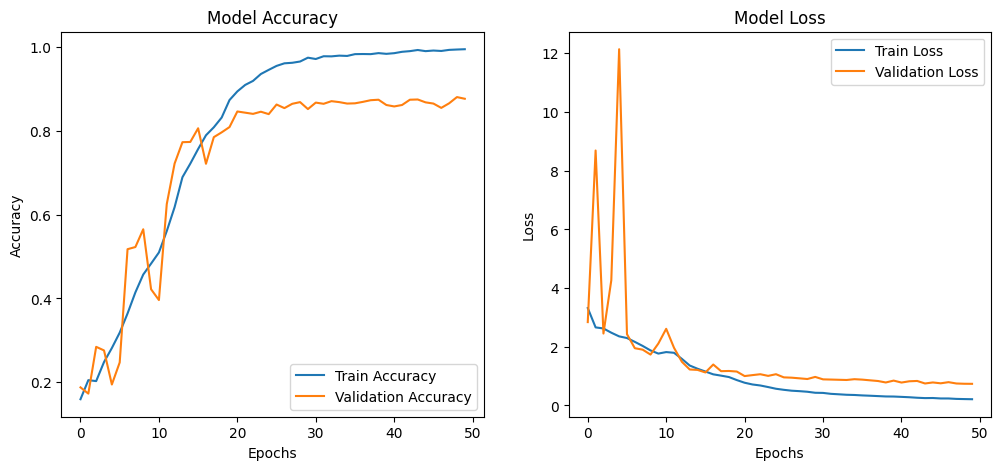

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ------------------------------
# Load preprocessed dataset
# ------------------------------
X = np.load("X_aug.npy")   # shape: (samples, 128, 128, 1)
y = np.load("y_aug.npy")   # shape: (samples,)

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=10)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# CNN Model
# ------------------------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1),
           kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu',
           kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu',
           kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 sound classes
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------
# Callbacks
# ------------------------------
early_stop = EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_sound_cnn.h5", monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

# ------------------------------
# Training
# ------------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# Save final model
model.save("sound_cnn_final1.h5")
print("✅ Training complete. Best model saved as best_sound_cnn.h5")

# ------------------------------
# Plot Accuracy & Loss
# ------------------------------
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.savefig("accuracy_plot1.png")   # save accuracy plot

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.savefig("loss_plot1.png")   # save loss plot

plt.show()
